

># Workshop
<img src="../assets/epfl-center-for-imaging.svg" alt="EPFL Center for Imaging" height="58" align="right"/>

# 3D Deconvolution Microscopy

**Daniel Sage**

Biomedical Imaging Group, École Polytechnique Fédérale de Lausanne (EPFL), Lausanne, Switzerland

*21 August 2026*

**Intended use**: Lecture companion material for in-class demonstrations

*These notebooks are not meant to replace a theoretical lecture, but to make abstract deconvolution concepts concrete and visually intuitive.*

**License**: BSD 3-Clause

*Citationware: if this material is useful to your research or teaching, please cite:*
> D. Sage, L. Donati, F. Soulez, D. Fortun, G. Schmit, A. Seitz, R. Guiet, C. Vonesch, M. Unser,
> "DeconvolutionLab2: An open-source software for deconvolution microscopy," *Methods*, vol. 115, pp. 28–41, 2017.

---

Deconvolution — Key Points for the Assessment
---

A minimal walk-through of the building blocks of deconvolution, illustrated with a single, simple algorithm: the **regularized inverse filter**

$$\hat{X}(\omega) = \frac{H^*(\omega)}{|H(\omega)|^2 + \lambda}\, Y(\omega).$$

1. A simplified whole pipeline (simulation + deconvolution) in one cell
2. Metrics — MSE, SNR, PSNR, SSIM, SI-SNR — and how image modifications affect them
3. Displaying images that do not share the same dynamic range
4. Noise: Gaussian vs Poisson
5. Blurring: PSF models (Gaussian, Airy, motion blur, double helix)
6. The regularized inverse filter, the role of $\lambda$, and a 5 × 5 study of the optimal $\lambda$

 The simulation code (PSFs, blurring, noise) lives in the separate module [`deconvolution_utils/simulation.py`](../deconvolution_utils/simulation.py).

In [ ]:
# JupyterLite (Pyodide) only: tifffile is not in the Pyodide distribution. Harmless in a normal Python setup.
%pip install -q numpy scipy matplotlib scikit-image tifffile

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.metrics import structural_similarity
import sys
sys.path.append("..")   # the shared package deconvolution_utils/ and models/ are one level up
from deconvolution_utils.display import show_images   # input: dict {title: image}
from deconvolution_utils.simulation import gaussian_psf, blur   # used from the teaser onwards

plt.rcParams.update({"image.cmap": "gray", "image.interpolation": "none"})
rng = np.random.default_rng(1234)

def deconvolution_inverse_filter(y, psf, lambda_=1e-6):
    # the minimal algorithm of deconvolution
    otf = np.zeros(y.shape)
    kh, kw = psf.shape
    otf[:kh, :kw] = psf
    otf = np.fft.fft2(np.roll(otf, (-(kh // 2), -(kw // 2)), axis=(0, 1)))
    deconvoled = np.real(np.fft.ifft2(np.conj(otf) * np.fft.fft2(y) / (np.abs(otf) ** 2 + lambda_)))
    return deconvoled

def add_gaussian_noise(image, sigma):
    return image + rng.normal(0.0, sigma, image.shape)

def add_poisson_noise(image, k):
    """Photon-counting noise: y = N/k, N ~ Poisson(k x), Pr(N=n) = (kx)^n e^{-kx} / n!
    k is the expected number of photons at intensity 1 (lower k = noisier)."""
    return rng.poisson(np.clip(image, 0, None) * k) / k

def si_snr(e, r):
    # scale-invariant SNR (torchmetrics convention) — defined here so the teaser can already report it
    e, r = e.ravel(), r.ravel()
    s_target = (e @ r) / (r @ r) * r
    return float(10 * np.log10(np.sum(s_target ** 2) / (np.sum((e - s_target) ** 2) + 1e-15)))


gt     | range [0.00, 1.00] | mean 0.21 | std 0.14 | size (300, 300)


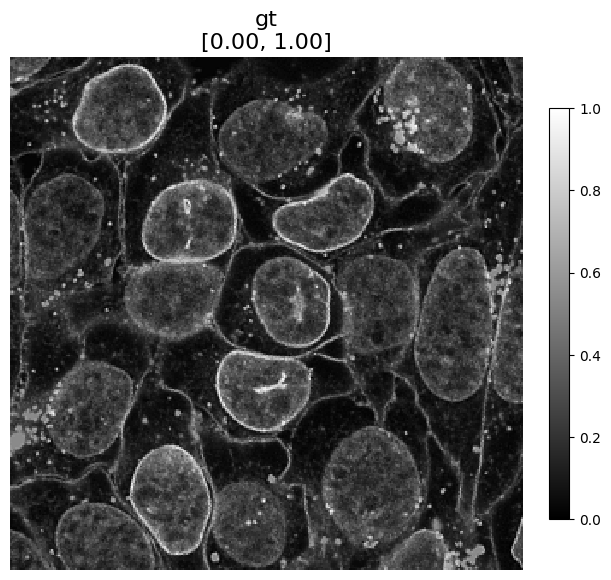

In [2]:
x = imread("../test-images/nucspot-hela-crop.tif").astype(np.float32)
x = (x-x.min())/(x.max()-x.min())
images = {"gt": x}
for name, img in images.items():
    print(f"{name:<6} | range [{img.min():.2f}, {img.max():.2f}] | mean {img.mean():.2f} | std {img.std():.2f} | size {img.shape}")
show_images(images)

## 0. Teaser: simulation → deconvolution → comparaison

Everything the notebook is about, in four lines: the ground-truth $x$ is **blurred** by a PSF and corrupted by **noise** (the simulation of a microscope), then the **regularized inverse filter** tries to recover $x$ from the measurement $y$. The rest of the notebook takes these ingredients apart one by one.

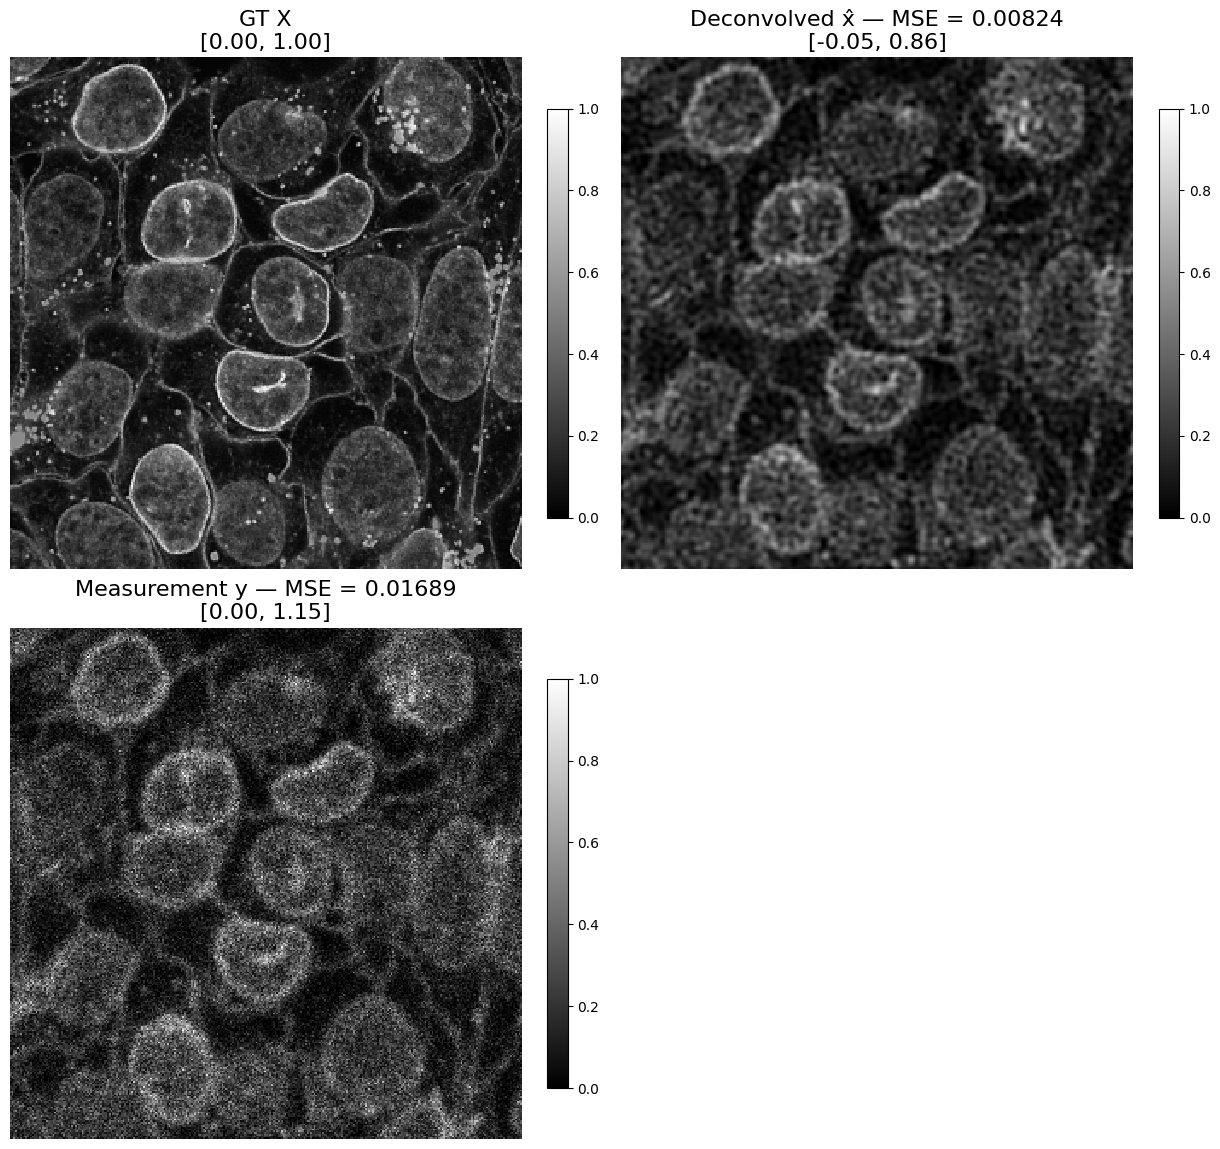

In [3]:
psf = gaussian_psf(1.8) 
y = add_poisson_noise(blur(x, psf), 20)
d = deconvolution_inverse_filter(y, psf, 1e-1)

show_images({f"GT X": x, 
             f"Deconvolved x̂ — MSE = {np.mean((d - x) ** 2):3.5f}": d,
             f"Measurement y — MSE = {np.mean((y - x) ** 2):3.5f}": y
             })

## 1. Metrics

| metric | definition | comment |
|---|---|---|
| MSE | $\frac{1}{N}\sum (\hat{x}-x)^2$ | raw squared error |
| SNR | $10\log_{10}\frac{\sum x^2}{\sum(\hat{x}-x)^2}$ | relative to the signal energy |
| PSNR | $10\log_{10}\frac{1}{\mathrm{MSE}}$ (max = 1) | relative to the dynamic range |
| SSIM | structural similarity | perceptual: luminance, contrast, structure |
| SI-SNR | $10 \log_{10} \left( \frac{\Vert{}\mathbf{s}_{\text{target}}\Vert{}^2}{\Vert{}\mathbf{\hat{x}} - \mathbf{s}_{\text{target}}\Vert{}^2 + \epsilon} \right)$  | SNR after projecting $\mathbf{s}_{\text{target}} = \frac{\mathbf{\hat{x}} \cdot \mathbf{x}}{\mathbf{x} \cdot \mathbf{x}} \mathbf{x}$ — **scale-invariant** (torchmetrics convention)   |


A few simple modifications are applied to the test image and every metric is evaluated against the original. Note how differently the metrics react: a global scaling ruins the MSE but leaves SI-SNR untouched, a 1 px shift is harmless to the eye but expensive for every pointwise metric.

variants           |   SI-SNR |      SNR |     PSNR |   SSIM |       MSE
------------------------------------------------------------------------------------------
scaled × 0.5       |   181.69 |     6.02 |    17.85 |  0.666 |  1.64e-02
offset + 0.2       |    11.44 |     2.15 |    13.98 |  0.763 |  4.00e-02
noise σ=0.05       |    14.22 |    14.22 |    26.05 |  0.802 |  2.49e-03
shift 1 px         |     8.45 |     8.89 |    20.71 |  0.606 |  8.48e-03
erase black 10x10  |    30.09 |    30.09 |    41.92 |  0.998 |  6.43e-05
erase white 10x10  |    20.85 |    20.83 |    32.65 |  0.997 |  5.43e-04


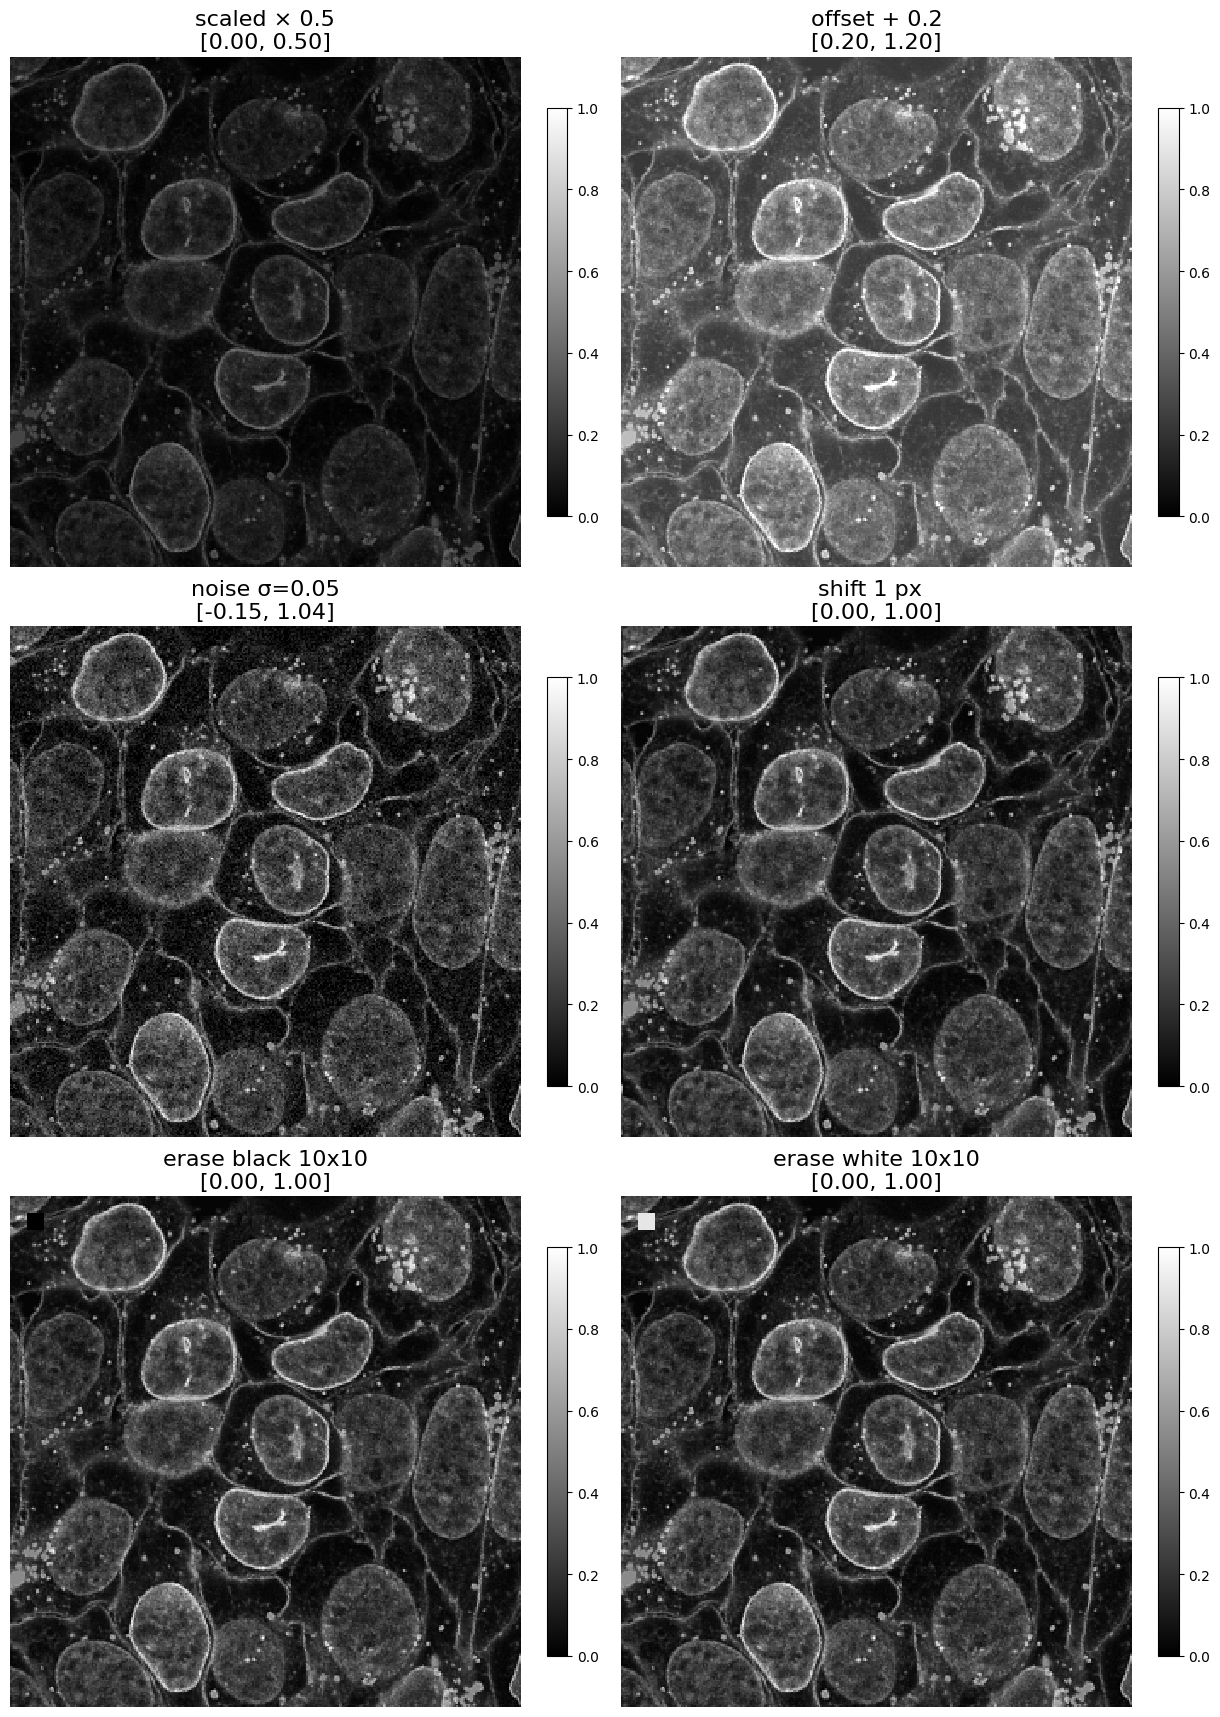

In [4]:
def mse(e, r): return float(np.mean((e - r) ** 2))
def snr(e, r): return float(10 * np.log10(np.sum(r ** 2) / (np.sum((r - e) ** 2) + 1e-15)))
def psnr(e, r): return float(-10 * np.log10(max(mse(e, r), 1e-15)))
def ssim(e, r): return float(structural_similarity(r, e, data_range=1.0))
def si_snr(e, r): # scale-invariant SNR (torchmetrics convention)
    e, r = e.ravel(), r.ravel()
    s_target = (e @ r) / (r @ r) * r
    return float(10 * np.log10(np.sum(s_target ** 2) / (np.sum((e - s_target) ** 2) + 1e-15)))


xb = x.copy()
xb[10:20, 10:20] = 0
xw = x.copy()
xw[10:20, 10:20] = 0.9
variants = {"scaled × 0.5": (0.5 * x),
            "offset + 0.2": (x + 0.2),
            "noise σ=0.05": add_gaussian_noise(x, 0.05),
            "shift 1 px  ": np.roll(x, 1, axis=1),
            "erase black 10x10": xb, "erase white 10x10": xw}
print(f"{'variants':<18} | {'SI-SNR':>8} | {'SNR':>8} | {'PSNR':>8} | {'SSIM':>6} | {'MSE':>9}")
print("-" * 90)
for name, img in variants.items():
    print(f"{name:<18} | {si_snr(img, x):>8.2f} | {snr(img, x):>8.2f} | "
                  f"{psnr(img, x):>8.2f} | {ssim(img, x):>6.3f} | "f"{mse(img, x):>9.2e}")

show_images(variants)

## 2. Displaying images

`show_images` lives in the module [`deconvolution_utils/display.py`](../deconvolution_utils/display.py) and takes a dict `{title: image}`, plus **two independent options**:

**`rescale`** — what happens to the pixel values before display (**3 states**), and the **colorbar always shows the range that is actually displayed**:
- `"clip"` — values **clipped to [0, 1]** and the clipped image is displayed;
- `"raw"` — values **kept intact** and displayed over their own full range: the true [min, max] is visible on the colorbar;
- `"rescale"` — values **stretched to [0, 1]** (min → 0, max → 1); the colorbar reads 0…1, the original levels are lost and the gray levels are no longer comparable between images.

**`display`** — the colormap:
- `"gray"` — grayscale (**default**);
- `"hilo"` — robust grayscale: the gray window covers the **[1 %, 99 %] quantiles** of the displayed values, so the **lowest 1 %** of the pixels show **blue** and the **highest 1 %** **red** (the colorbar shows the quantile window);
- `"viridis"` — false color.


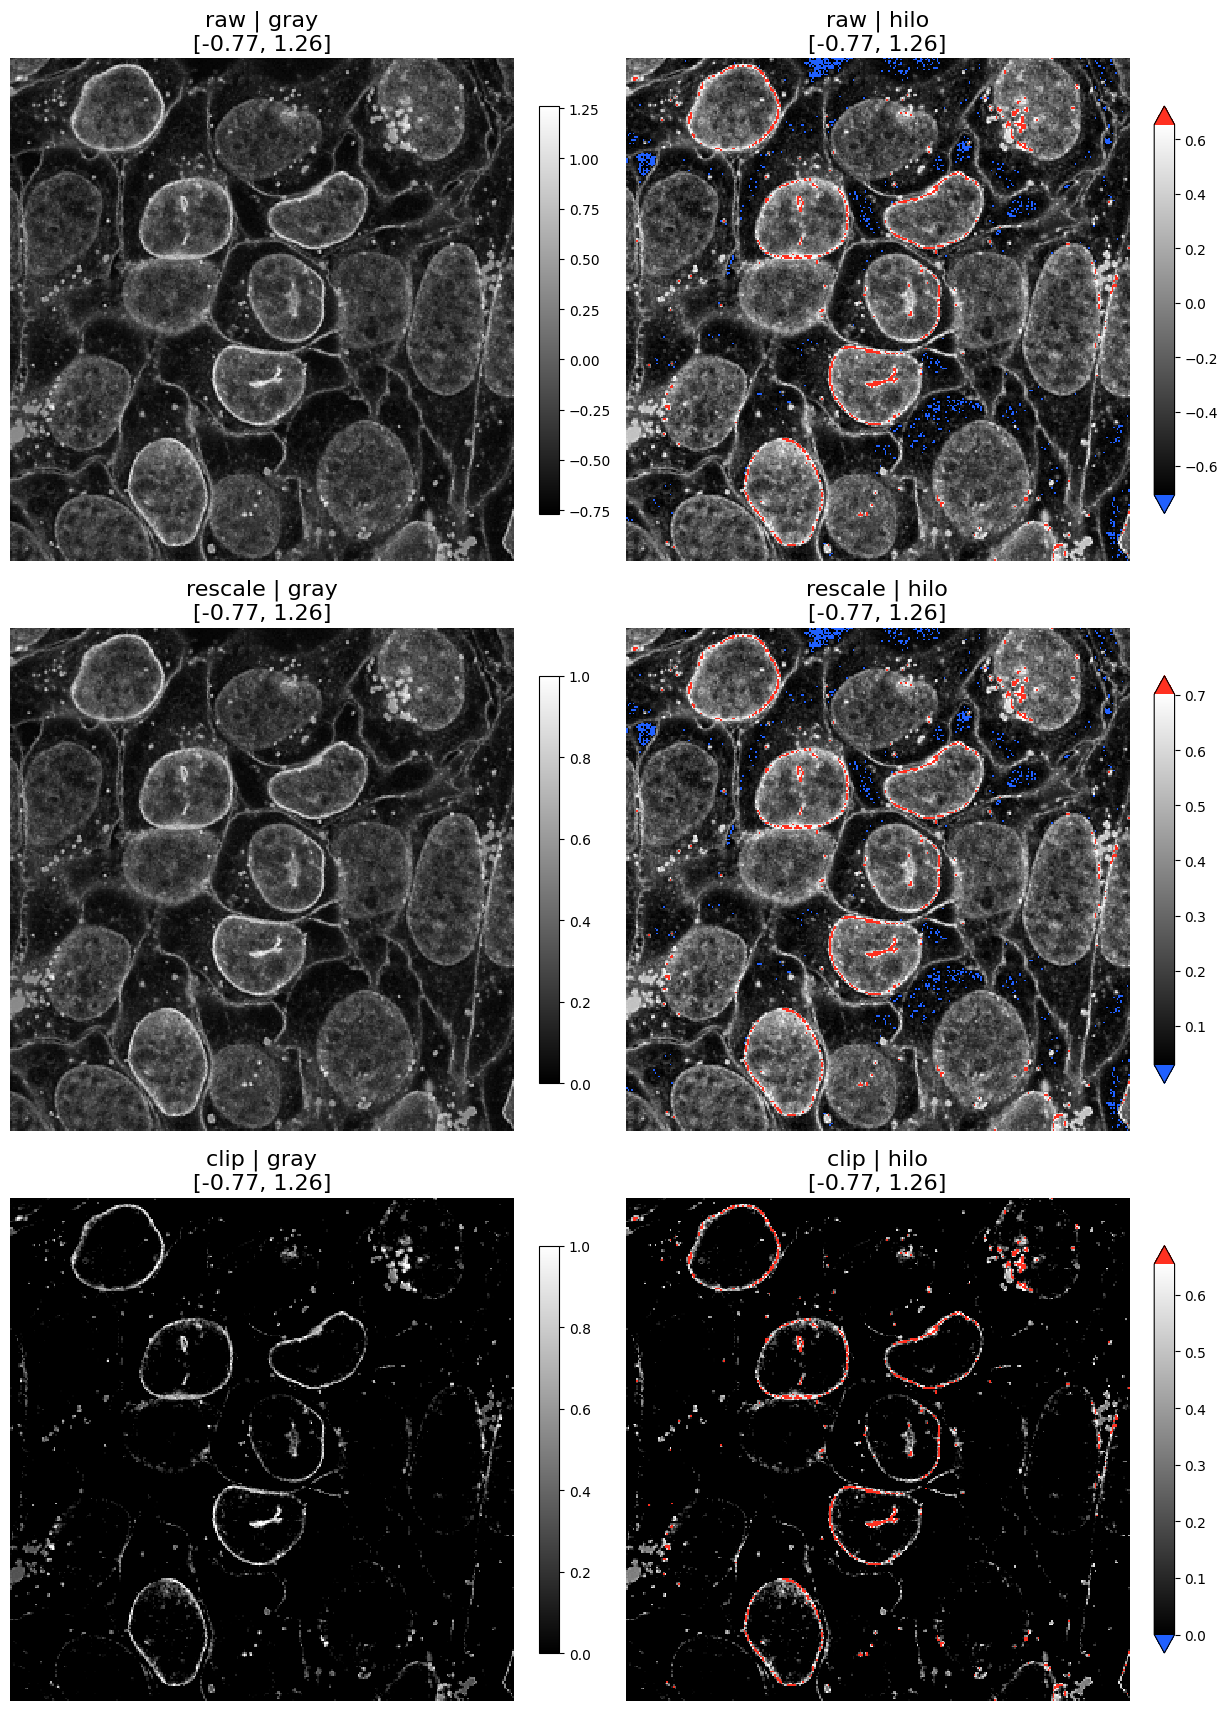

In [5]:
x_overshot = add_gaussian_noise(x*2 - 0.75, 0.01) 
SETTINGS = [("raw", "gray"), ("raw", "hilo"),
            ("rescale", "gray"), ("rescale", "hilo"),
            ("clip", "gray"), ("clip", "hilo"),]

show_images({f'{r} | {d}': x_overshot for r, d in SETTINGS},
            rescale=[r for r, d in SETTINGS],
            display=[d for r, d in SETTINGS])

## 3. Noise: Gaussian vs Poisson

- **Gaussian noise** — additive, same variance everywhere (readout/electronic noise):
$$y = x + n, \qquad n \sim \mathcal{N}(0, \sigma^2).$$
- **Poisson noise** — photon counting: at a pixel of intensity $x$, the number of detected photons $N$ follows the Poisson distribution
$$\Pr(N = n) = \frac{(k\,x)^n\, e^{-k x}}{n!}, \qquad y = \frac{N}{k},$$
where the parameter $k$ is the expected number of photons at intensity 1. Then $\mathbb{E}[y] = x$ and $\mathrm{Var}[y] = x/k$: the noise is **signal-dependent** (stronger in bright regions), and a smaller $k$ (fewer photons) means more noise.

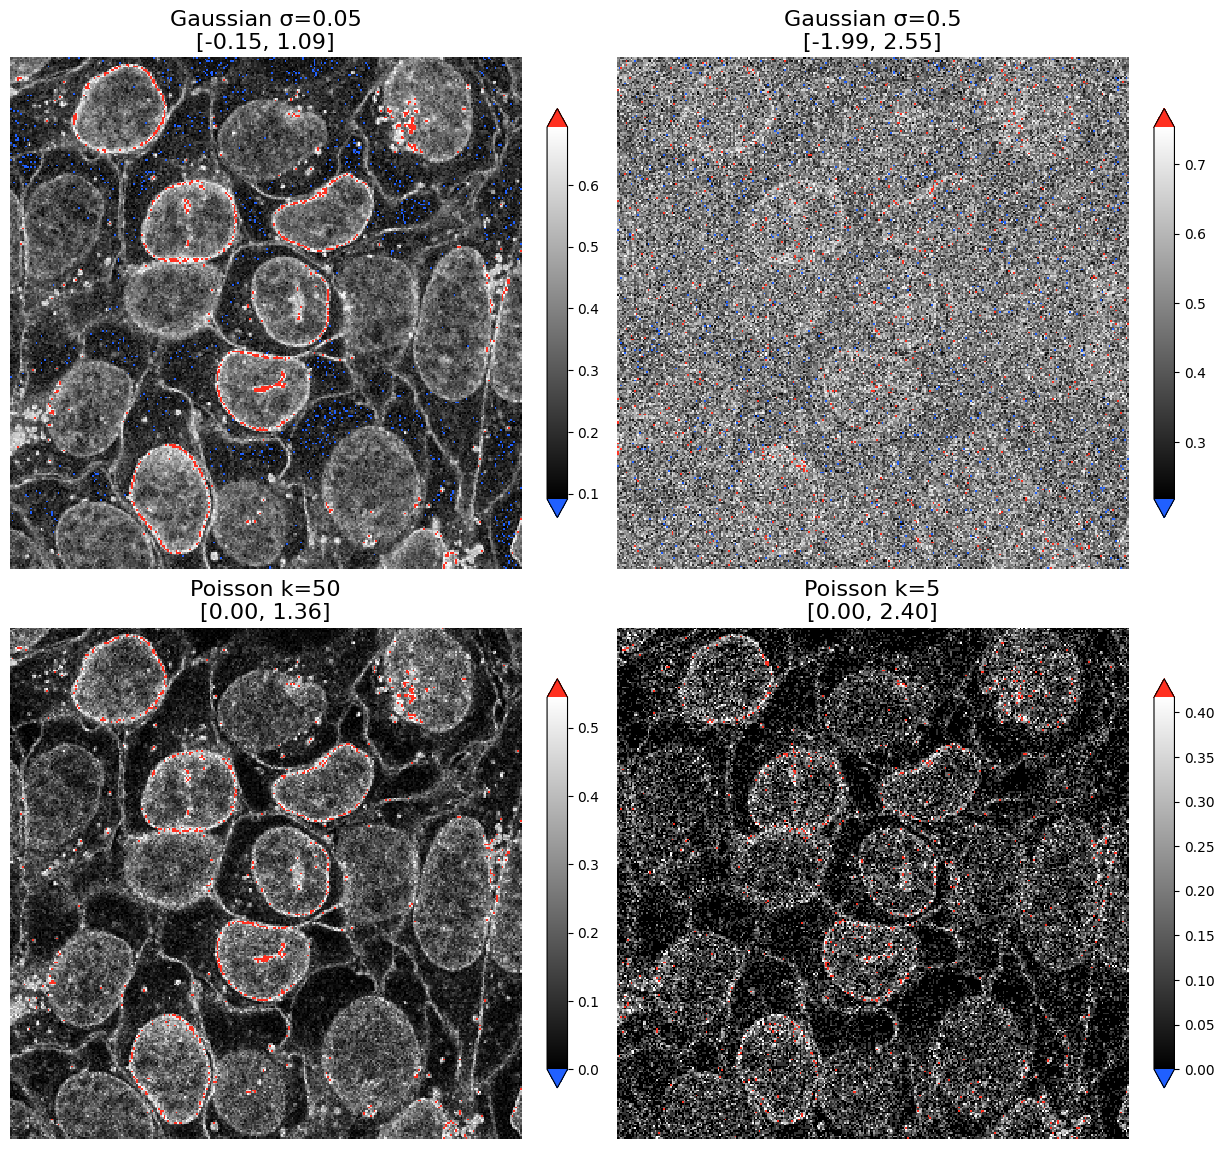

In [6]:
GAUSSIANS = [0.05, 0.5]     # gaussian: two standard deviations (weak, strong)
POISSONS  = [50, 5]         # poisson: two photon counts k at intensity 1 (lower = noisier)

noisy = {}
for s in GAUSSIANS: noisy[f"Gaussian σ={s}"] = add_gaussian_noise(x, s)
for k in POISSONS: noisy[f"Poisson k={k}"] = add_poisson_noise(x, k)

show_images(noisy, rescale="rescale", display="hilo")

## 4. Blurring: point-spread functions

The PSF is the image of a point source (its code is in [`deconvolution_utils/simulation.py`](../deconvolution_utils/simulation.py)):

- **Gaussian** — generic smooth blur, $h(r) \propto e^{-r^2/2\sigma^2}$;
- **Airy** — diffraction-limited lens (circular aperture), $h(r) \propto \left(2 J_1(v)/v\right)^2$ with $v = 3.83\, r/R$, where $R = 0.61\,\lambda/\mathrm{NA}$ is the first dark ring;
- **Motion** — linear motion blur, a straight streak (length `PSF_SIZE`, 30°): every point leaves a trail;
- **Double helix** — an engineered PSF made of **two Gaussian lobes** (separation `PSF_SIZE`); in 3-D localization microscopy the angle of the lobe pair rotates with the emitter's depth $z$ — here it simply duplicates the image into a ghost pair.

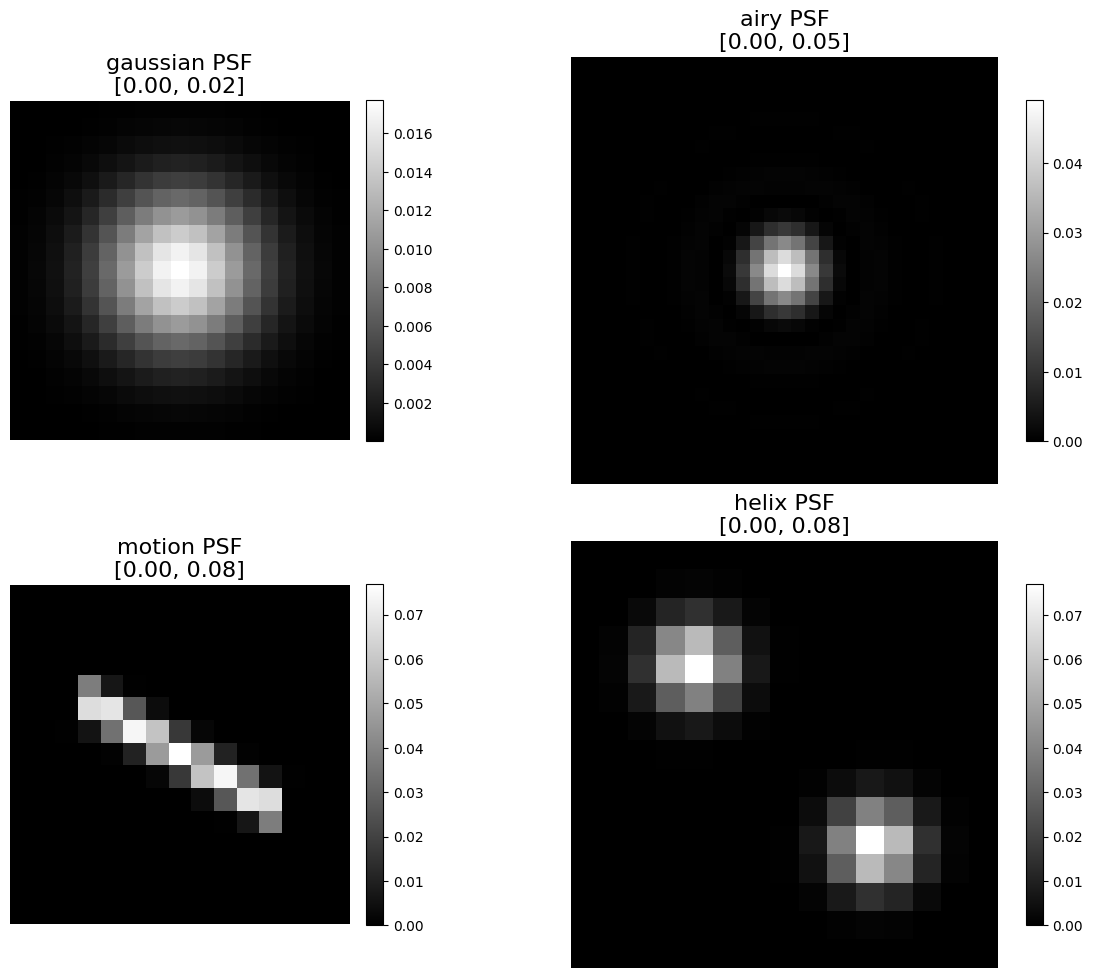

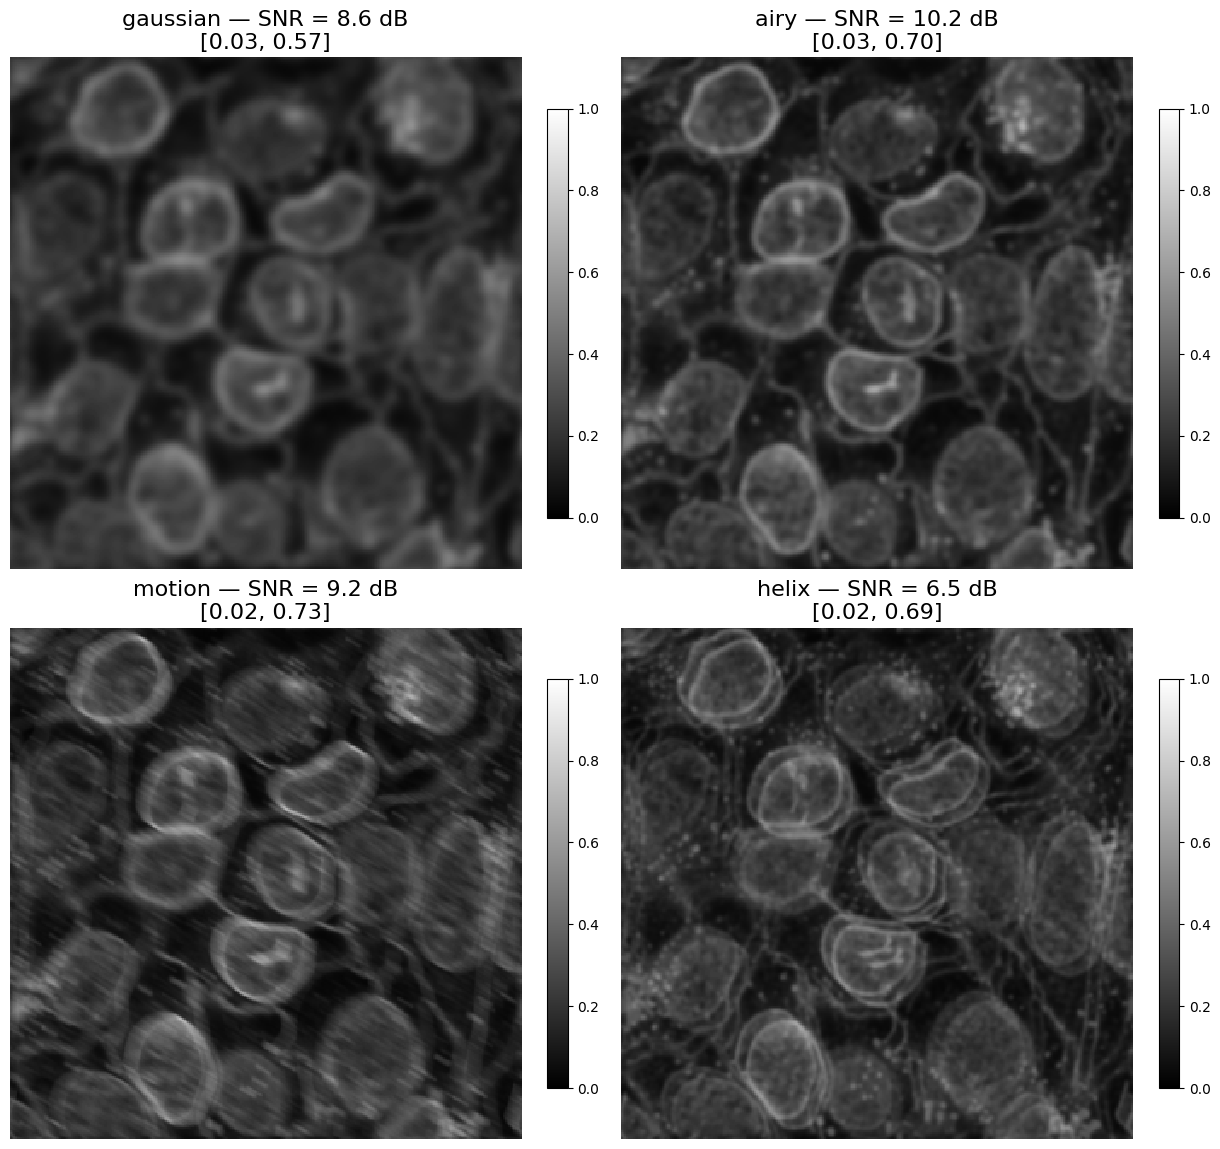

In [7]:
import sys
sys.path.append("..")   # the shared package deconvolution_utils/ and models/ are one level up
from deconvolution_utils.simulation import (gaussian_psf, airy_psf, motion_psf, double_helix_psf, blur)

psfs = {"gaussian": gaussian_psf(3), "airy": airy_psf(5), "motion": motion_psf(10), "helix": double_helix_psf(9)}
gallery = {f"{name} PSF": psf for name, psf in psfs.items()}
show_images(gallery, rescale="raw", display="gray", px_per_inch=6)
panels = {}
for name, psf in psfs.items(): 
    img = blur(x, psf)
    panels[f"{name} — SNR = {snr(img, x):.1f} dB"] = img
show_images(panels)

## 5. Regularized inverse filter

$$\hat{X}(\omega) = \frac{H^*(\omega)}{|H(\omega)|^2 + \lambda}\, Y(\omega)$$

- $\lambda \to 0$: exact inversion $Y/H$ — the noise explodes at frequencies where $|H|$ is small (the zeros of the OTF);
- large $\lambda$: stable but over-smoothed — high frequencies are given up.

(13, 13)


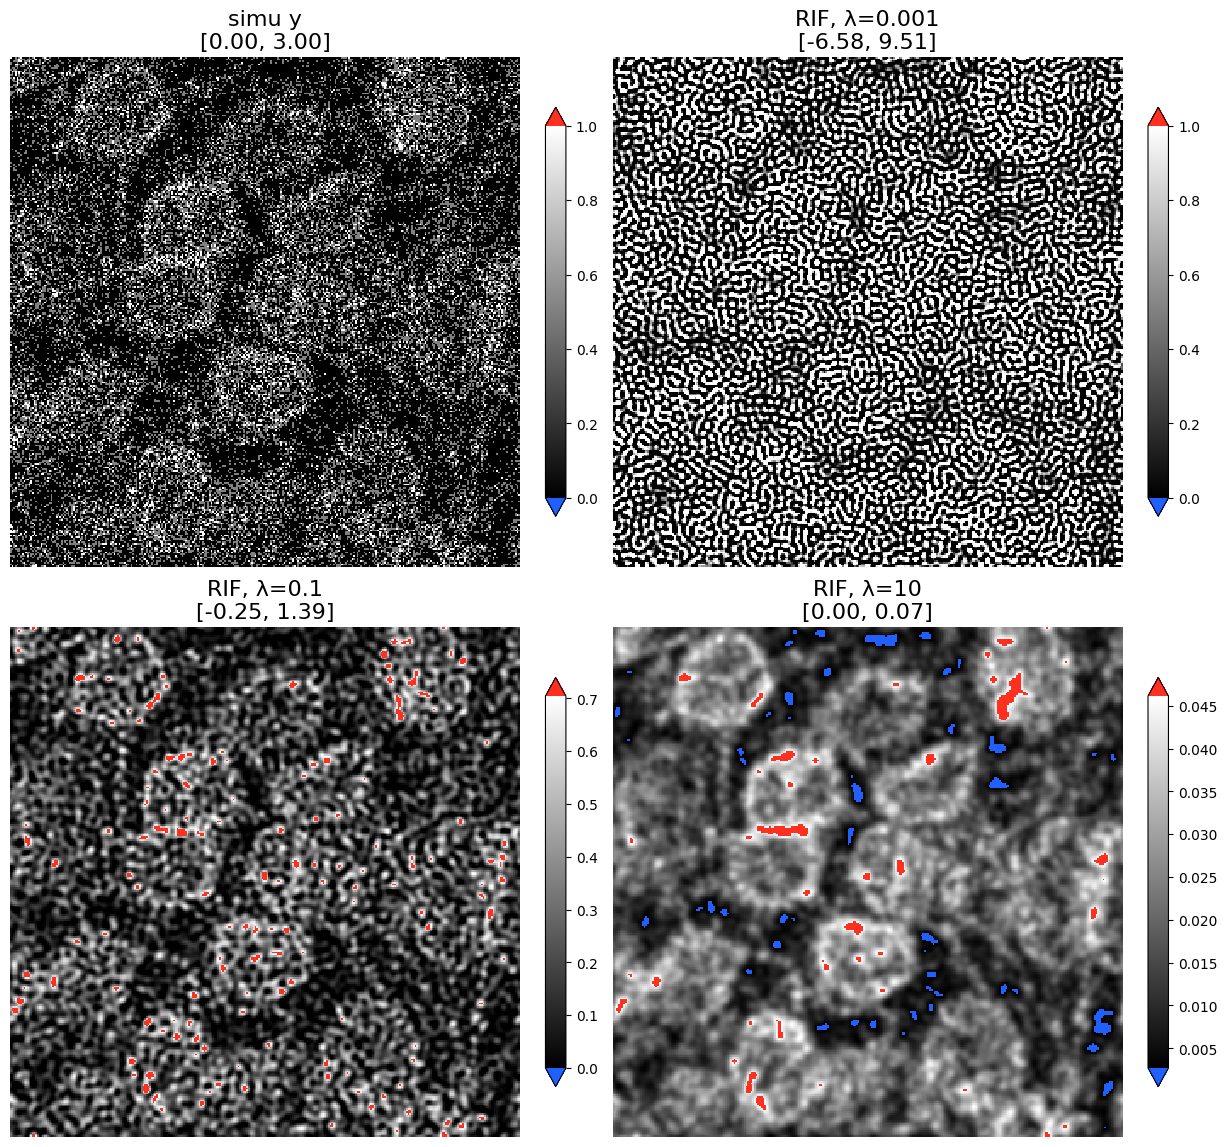

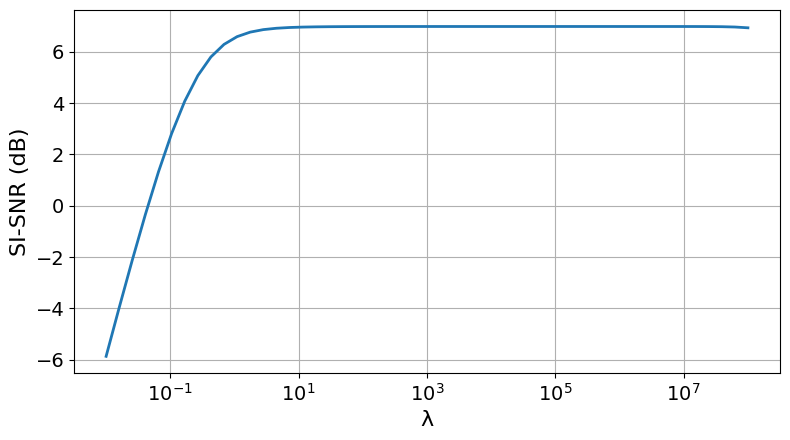

In [8]:
psf = gaussian_psf(2)
y = add_poisson_noise(blur(x, psf), 2)
variants = [("simu y", y)]
print(psf.shape)
for lam in [1e-3, 1e-1, 1e1] : variants.append((f"RIF, λ={lam:g}", deconvolution_inverse_filter(y, psf, lam)))
panels = {}
for name, img in variants: panels[name] = img
show_images(panels, rescale="clip", display="hilo")

LAMBDA_GRID = np.logspace(-2, 8, 50)
curve = [si_snr(deconvolution_inverse_filter(y, psf, l), x) for l in LAMBDA_GRID]
plt.figure(figsize=(8, 4.5))
plt.semilogx(LAMBDA_GRID, curve, linewidth=2)
plt.xlabel("λ", fontsize=16); plt.ylabel("SI-SNR (dB)", fontsize=16)
plt.tick_params(labelsize=14); plt.grid(); plt.tight_layout(); plt.show()

## 6. Deconvolution on various degradation conditions

`NOISE_LEVELS` × `BLUR_LEVELS` degradation conditions are simulated on the test image — Gaussian noise from none to strong × Gaussian blur from none to strong; **both lists can have any length**. For each condition the SI-SNR is scanned over the same fine grid `LAMBDA_GRID` as above and two numbers are recorded: the **optimal $\lambda$** and the **SI-SNR it achieves**.

The scan is fast (about one second for 5 × 5 × 50): the FFTs of $y$ and of the PSF are computed **once per condition**, and all the $\lambda$ are inverted in a **single batched inverse FFT**. At this image size (300 × 300) a GPU brings nothing — the transfer to the GPU costs more than the computation, and torch on the Apple GPU was measured slower than the NumPy CPU version.

Below the heatmaps, **typical cases** (`TYPICAL_CELLS`, by their cell number, printed in the corner of every cell of the SI-SNR heatmap) are reconstructed at their optimal $\lambda$ and shown as images.


5 noise levels x 5 blur levels x 50 λ scanned in 1.5 s


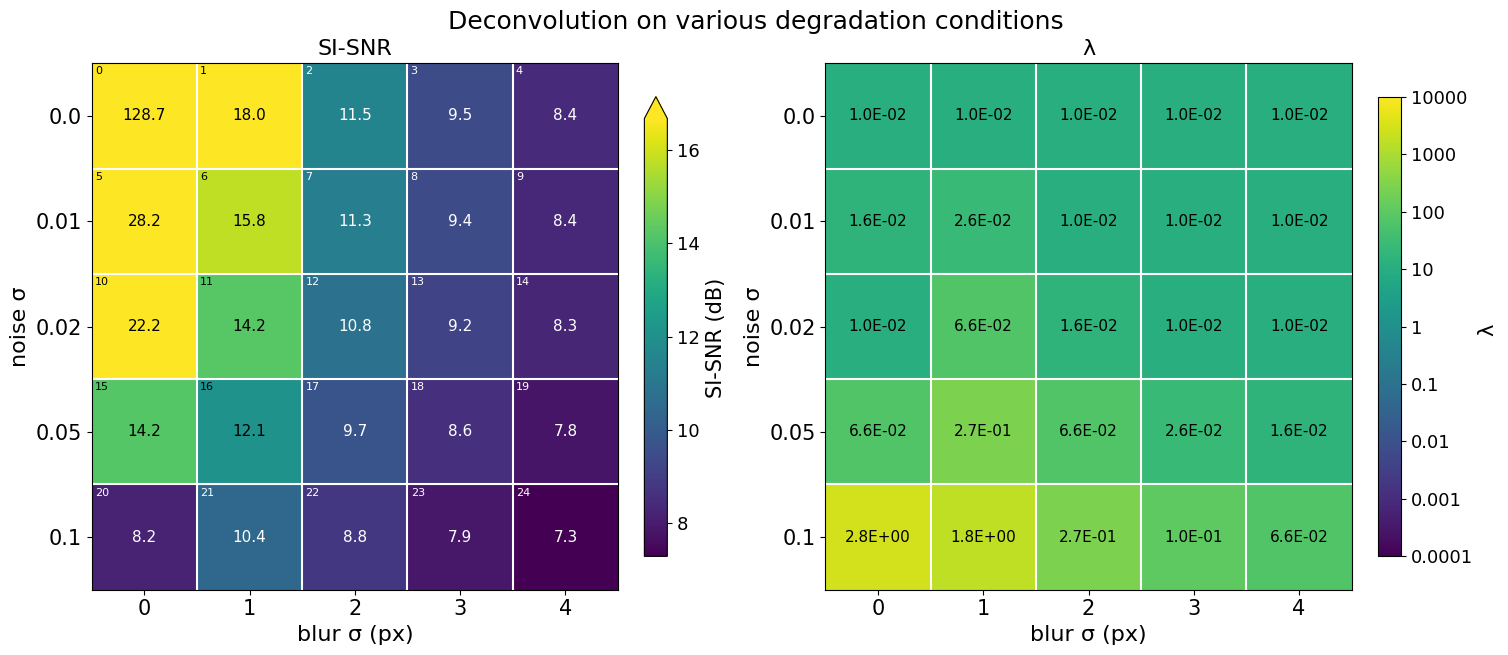

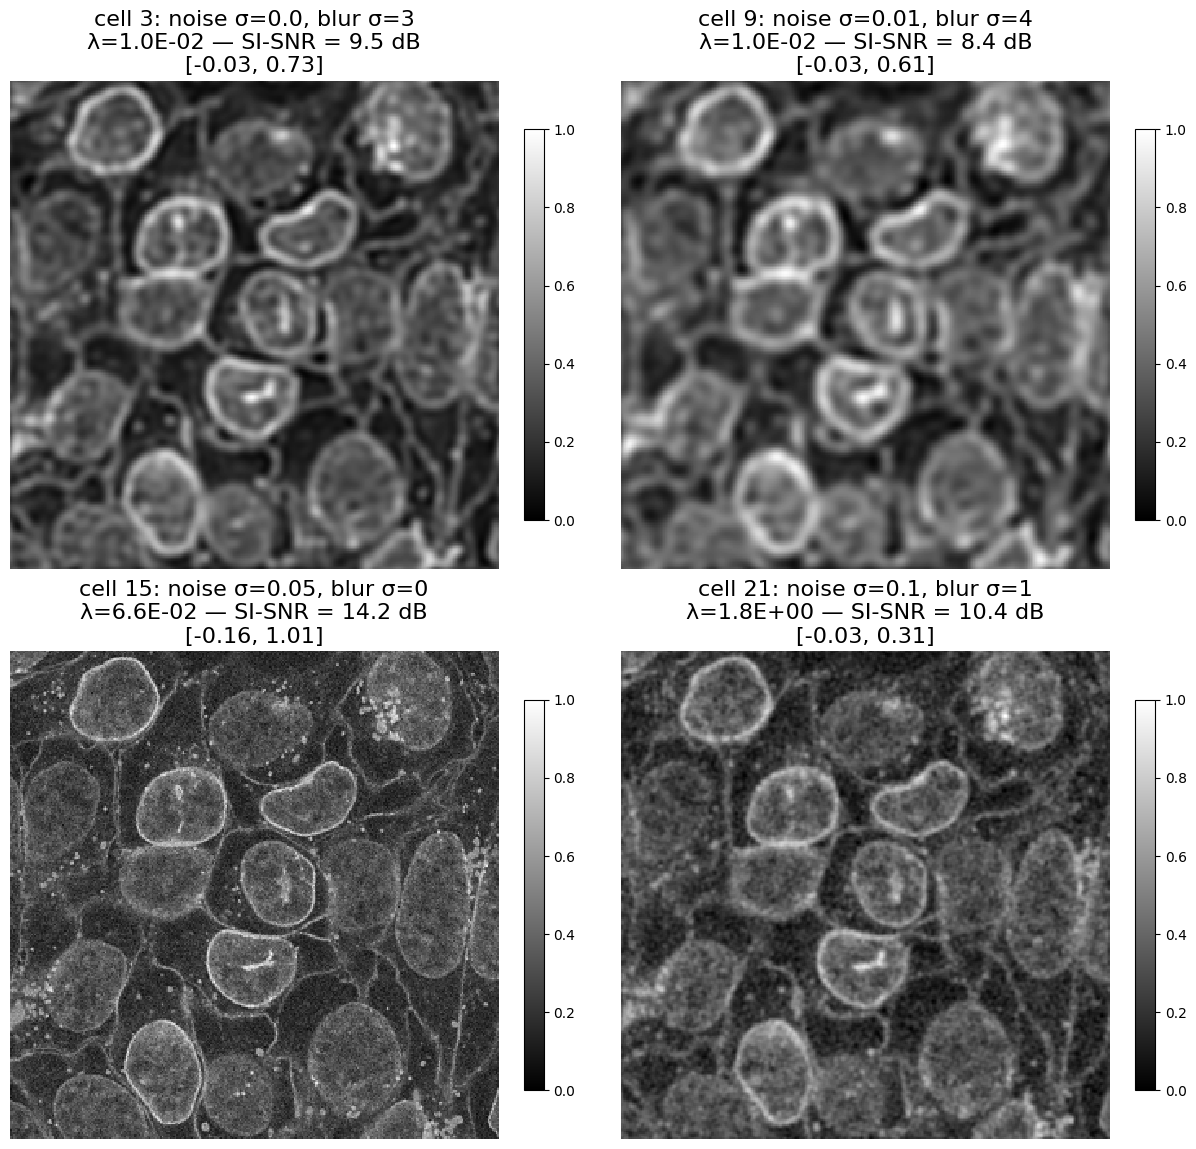

In [9]:
from time import time

NOISE_LEVELS = [0.0, 0.01, 0.02, 0.05, 0.1]   # Gaussian noise σ (none -> strong), any number of levels
BLUR_LEVELS = [0, 1, 2, 3, 4]                 # Gaussian PSF σ (0 = no blur -> strong), any number of levels
TYPICAL_CELLS = [3, 9, 15, 21]                # cell number = row * len(BLUR_LEVELS) + column, shown as images

def scan_lambda(y, psf, lambdas, reference):
    # SI-SNR of the regularized inverse filter for every λ: the FFTs of y and of the PSF are computed once
    otf = np.zeros(y.shape)
    kh, kw = psf.shape
    otf[:kh, :kw] = psf
    otf = np.fft.fft2(np.roll(otf, (-(kh // 2), -(kw // 2)), axis=(0, 1)))
    numerator = np.conj(otf) * np.fft.fft2(y)
    power = np.abs(otf) ** 2
    lam = np.asarray(lambdas)[:, None, None]                                        # (n_λ, 1, 1)
    estimates = np.real(np.fft.ifft2(numerator / (power + lam), axes=(-2, -1)))   # (n_λ, H, W): one batched inverse FFT
    curve = np.zeros(len(lambdas))
    for k in range(len(lambdas)): curve[k] = si_snr(estimates[k], reference)
    return curve

# the λ range is unique in the notebook: the same LAMBDA_GRID as section 5
n_noise, n_blur = len(NOISE_LEVELS), len(BLUR_LEVELS)
lam_opt = np.zeros((n_noise, n_blur))   # optimal λ per condition
snr_opt = np.zeros_like(lam_opt)        # SI-SNR achieved at that λ
chrono = time()
for j, bs in enumerate(BLUR_LEVELS):
    psf_j = gaussian_psf(bs) if bs > 0 else np.ones((1, 1))
    x_b = blur(x, psf_j)
    for i, ns in enumerate(NOISE_LEVELS):
        y_ij = add_gaussian_noise(x_b, ns)
        curve = scan_lambda(y_ij, psf_j, LAMBDA_GRID, x)
        lam_opt[i, j] = LAMBDA_GRID[int(np.argmax(curve))]
        snr_opt[i, j] = curve.max()
print(f"{n_noise} noise levels x {n_blur} blur levels x {len(LAMBDA_GRID)} λ scanned in {time() - chrono:.1f} s")

fs = max(8, 16 - max(n_noise, n_blur))   # font size of the values inside the cells, smaller for finer grids
fig, axes = plt.subplots(1, 2, figsize=(15, 6.4), constrained_layout=True)
fig.suptitle(f'Deconvolution on various degradation conditions', fontsize=18)
for ax in axes:
    ax.set_xticks(range(n_blur), [str(b) for b in BLUR_LEVELS], fontsize=15)
    ax.set_yticks(range(n_noise), [str(n) for n in NOISE_LEVELS], fontsize=15)
    ax.set_xlabel("blur σ (px)", fontsize=16); ax.set_ylabel("noise σ", fontsize=16)
    ax.set_xticks(np.arange(0.5, n_blur - 1), minor=True)   # white grid between cells
    ax.set_yticks(np.arange(0.5, n_noise - 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)

# color scale capped at the 85th percentile: the easy no-blur/no-noise corner
# (> 100 dB) would otherwise crush all the contrast of the other cells
vmax0 = np.percentile(snr_opt, 85)
im0 = axes[0].imshow(snr_opt, cmap="viridis", vmax=vmax0)
axes[0].set_title("SI-SNR", fontsize=16)
for i in range(n_noise):
    for j in range(n_blur):
        color = "black" if snr_opt[i, j] > (snr_opt.min() + vmax0) / 2 else "white"   # readable on bright and dark cells
        axes[0].text(j, i, f"{snr_opt[i, j]:.1f}", ha="center", va="center", fontsize=fs, color=color)
        axes[0].text(j - 0.47, i - 0.47, str(i * n_blur + j), ha="left", va="top", fontsize=fs - 3, color=color)   # cell number
cb0 = fig.colorbar(im0, ax=axes[0], shrink=0.85, extend="max")
cb0.set_label("SI-SNR (dB)", fontsize=15); cb0.ax.tick_params(labelsize=13)

im1 = axes[1].imshow(np.log10(lam_opt), cmap="viridis", vmin=-7, vmax=1)
axes[1].set_title("λ", fontsize=16)
for i in range(n_noise):
    for j in range(n_blur):
        axes[1].text(j, i, f"{lam_opt[i, j]:0.1E}", ha="center", va="center", fontsize=fs)
cb1 = fig.colorbar(im1, ax=axes[1], shrink=0.85)
cb1.set_label("λ ", fontsize=15)
cb1.set_ticks(range(-7, 2)); cb1.set_ticklabels([f"{10.0 ** t / 0.001:g}" for t in range(-7, 2)])   # λ in units of 0.001
cb1.ax.tick_params(labelsize=13)
plt.show()

# typical cases, reconstructed at their optimal λ
typical = {}
for idx in TYPICAL_CELLS:
    i, j = idx // n_blur, idx % n_blur
    ns, bs = NOISE_LEVELS[i], BLUR_LEVELS[j]
    psf_ij = gaussian_psf(bs) if bs > 0 else np.ones((1, 1))
    y_ij = blur(x, psf_ij)
    y_ij = add_gaussian_noise(y_ij, ns)
    x_ij = deconvolution_inverse_filter(y_ij, psf_ij, lam_opt[i, j])
    typical[f"cell {idx}: noise σ={ns}, blur σ={bs}\nλ={(lam_opt[i, j]):.1E} — SI-SNR = {snr_opt[i, j]:.1f} dB"] = x_ij
show_images(typical, rescale="rescale")
